# Tracking of several entities using Trackpy

# Importations

In [1]:
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience

import pims
import trackpy as tp

import cv2

from tqdm import tqdm
import os
import shutil

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# change the following to %matplotlib notebook for interactive plotting
%matplotlib inline

# Optionally, tweak styles.
mpl.rc('figure',  figsize=(10, 5))
mpl.rc('image', cmap='gray')
mpl.rc('text', usetex=True)

# Auxiliary functions

In [3]:
def normalize8(I):
    mn = I.min()
    mx = I.max()
    I = ((I - mn) / (mx - mn)) * 255
    return I.astype(np.uint8)

# Inputs

In [4]:
# Where to find the data
path2vid = '/home/nfares/postdoc/experiments/data/2026/20260427_day1_diffusion_SiO2_in_capillary_100um_20fps/diffusion_px_65nm_500fps.mp4'

# Frame rate
fps = 500

# Pixel size (in m)
px = 65e-9

# Get the frames 

In [ ]:
@pims.pipeline
def gray(image, channel=2):
    return image[:, :, channel]  # Take just one channel
    # return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

frames = gray(pims.open(path2vid))
# frames = pims.open(path2vid)

# PyAV-based reading

In [6]:
frames

(PyAVReaderTimed,) processed through proc_func. Original repr:
    <Frames>
    Format: QuickTime / MOV
    Source: /home/nfares/postdoc/experiments/data/2026/20260427_day1_diffusion_SiO2_in_capillary_100um_20fps/diffusion_px_65nm_500fps.mp4
    Duration: 49.438 seconds
    Frame rate: 63.979 fps
    Length: 3163 frames
    Frame Shape: (512, 512, 3)
    

# Compute the background

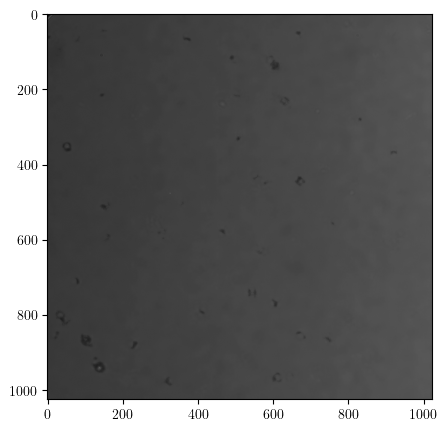

In [118]:
indexes = np.arange(0, 800, 10)
bg = np.median(frames[indexes], axis=0)
plt.figure()
plt.imshow(bg)
plt.show()

In [119]:
# Uncomment next cell if you want to load the background

In [120]:
# bg = cv2.imread('background.tiff')
# bg = gray(bg)
# plt.figure()
# plt.imshow(bg)
# plt.show()

In [121]:
# Uncomment next cell if you want to use a ''black'' background

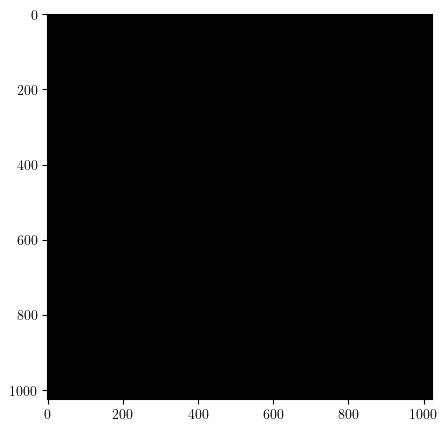

In [122]:
bg = np.zeros_like(frames[indexes[0]])

plt.figure()
plt.imshow(bg)
plt.show()

# One image: Track Particles

In [123]:
index = 0

In [124]:
im1 = frames[index]

In [125]:
# im1 = normalize8(im1)

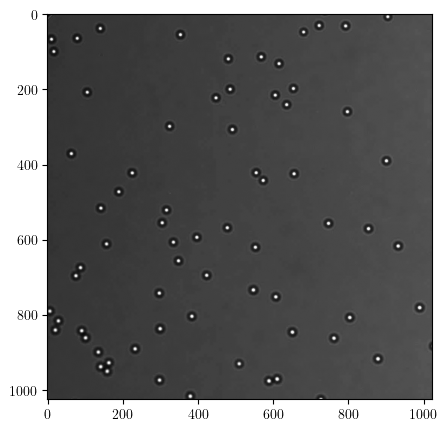

In [126]:
plt.imshow(im1);

In [127]:
# im1

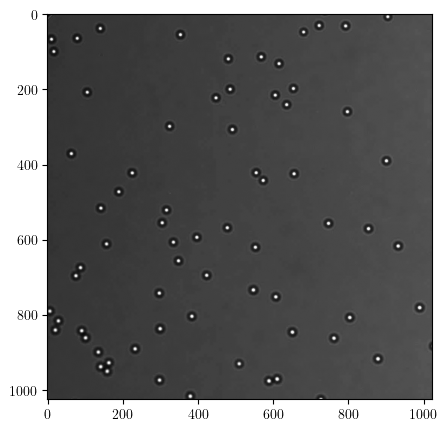

In [128]:
# im2 = (im1 - bg) 
im2 = im1
plt.imshow(im2)

In [129]:
# im2

In [130]:
f2 = tp.locate(im2, 15, invert=False, engine='python')

In [131]:
f2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame
0,6.647138,903.633833,5743.908561,2.798443,0.046188,152.203302,18305.0,0.046658,0
1,10.522876,300.437908,98.257828,3.963889,0.277230,1.926624,10633.0,-0.553544,0
2,10.314465,634.987421,102.111076,3.484016,0.112475,1.926624,11623.0,0.838744,0
3,10.505435,970.478261,118.166276,3.676453,0.056704,1.926624,13322.0,0.157761,0
4,11.456790,691.567901,104.037700,3.016416,0.304412,3.853248,12291.0,0.310975,0


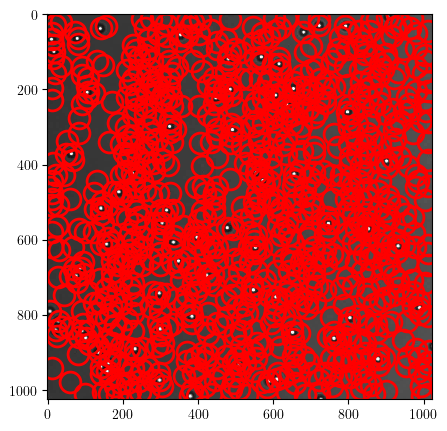

In [132]:
tp.annotate(f2, im2);

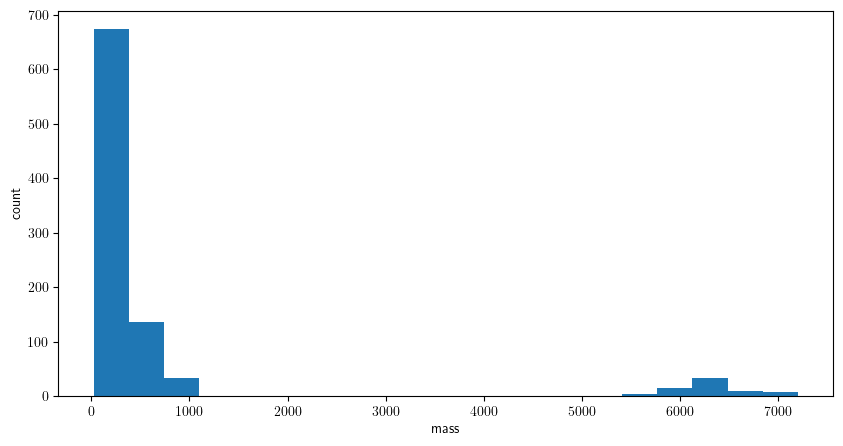

In [133]:
fig, ax = plt.subplots()
ax.hist(f2['mass'], bins=20)

# Optionally, label the axes.
ax.set(xlabel='mass', ylabel='count');

In [134]:
f2 = tp.locate(im2, 15, invert=False, minmass=3500, separation=15)
f2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame
0,6.647138,903.633833,5743.908561,2.798443,0.046188,152.203302,18305.0,0.046658,0
22,30.101773,721.553772,6120.884670,2.868887,0.045068,153.487718,18733.0,0.043996,0
26,31.332258,791.783767,6171.619104,2.894233,0.040002,147.065637,19133.0,0.041770,0
30,37.987920,140.954184,5901.249526,2.744260,0.036935,161.194214,16947.0,0.057740,0
44,47.495504,680.335319,5713.082575,2.784831,0.040414,155.414342,17465.0,0.052943,0


In [135]:
# f2

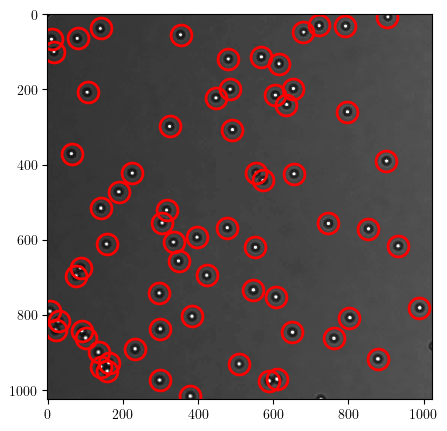

In [136]:
tp.annotate(f2, im2);

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'y'}>]],
      dtype=object)

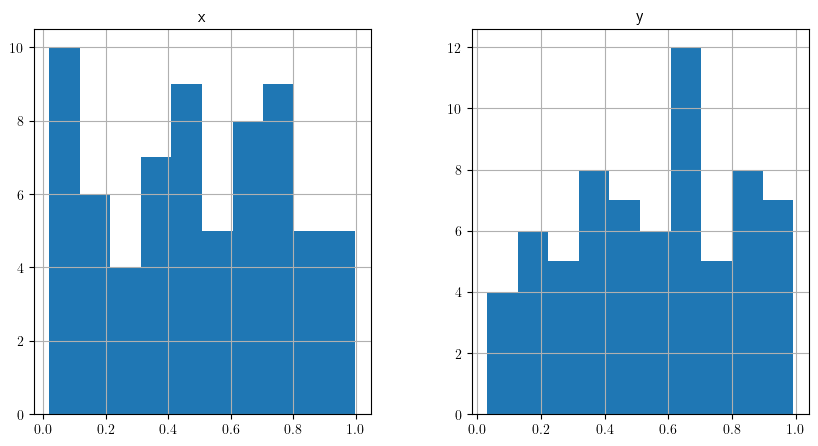

In [137]:
# Check sub-pixel accuracy
tp.subpx_bias(f2)
# Here I changed DataFrame.applymap to DataFrame.map in the source code, because of an update in pandas.
# Source code:
# ~/miniforge3/envs/ista/lib/python3.12/site-packages/trackpy/plots.py

# Blur image and track

In [138]:
# im3 = np.abs(im2)
# im4 = cv2.GaussianBlur(im3, (3,3), cv2.BORDER_DEFAULT)

In [139]:
# plt.imshow(im4)

In [140]:
# im4

In [141]:
# f4 = tp.locate(im4, 51, invert=False, engine='python')

In [142]:
# f4.head()

In [143]:
# tp.annotate(f4, im4)

In [144]:
# fig, ax = plt.subplots()
# ax.hist(f4['mass'], bins=20)

# # Optionally, label the axes.
# ax.set(xlabel='mass', ylabel='count');

In [145]:
# f4b = tp.locate(im4, 15, invert=False, engine='python', minmass=3500, separation=15)

In [146]:
# f4b.head()

In [147]:
# tp.annotate(f4b, im4) 

In [148]:
# f4c = tp.locate(im4, 21, invert=True, engine='python', minmass=200)

In [149]:
# # Keep spherical objects

# index_ecc = f4b['ecc'] < 0.15
# f4c = f4b[index_ecc]

In [150]:
# f4c.head()

In [151]:
# tp.annotate(f4c, im4)

# Using rings from bright-field microscopy

In [152]:
R = 9

In [153]:
%%time 
# Locate, without initial guess
fbf = tp.locate_brightfield_ring(frames[index], 2.0*R+1) # Use a slightly larger radius than expected

CPU times: user 435 ms, sys: 227 ms, total: 662 ms
Wall time: 10.2 s


In [154]:
fbf.head()

,y,x,r,frame
0,29.818451,721.619346,9.159848,0
1,31.281677,791.908465,8.883243,0
2,38.023599,140.755742,9.069901,0
3,47.396885,680.650483,8.174317,0
4,54.168572,353.482348,9.614768,0


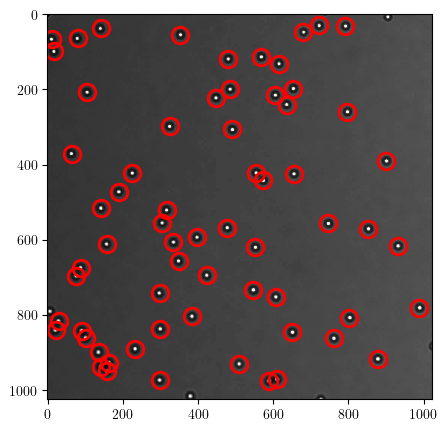

In [155]:
tp.annotate(fbf, frames[index], plot_style={'markersize': 12});

In [156]:
# Locate, with initial guess from no-ring locate function

# To be implemented as it is supposed to speed up the tracking, but not accuracy (according to trackpy doc). 

In [157]:
%%time 

fbf2 = tp.locate_brightfield_ring(frames[index], 2.0*R+1, previous_coords=f2)

CPU times: user 105 ms, sys: 82.7 ms, total: 188 ms
Wall time: 2.26 s


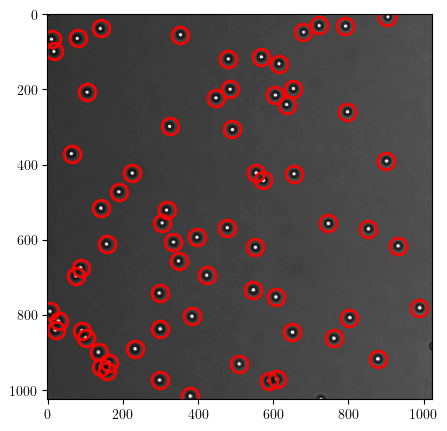

In [158]:
tp.annotate(fbf2, frames[index], plot_style={'markersize': 12});

In [159]:
# Let's see later, the accuracy seems to be dependent of the normal tracking and reduced

# Delete to clear your mind

In [160]:
del f2, fbf, fbf2

# Several Images: Tracking and Linking

## Inputs

In [161]:
start = 0
stop = len(frames)

In [162]:
R1 = 15 # radius for spot tracking
minmass = 3500
separation = 15

R2 = 9 # radius for ring tracking

# param_blur = (3,3)

In [163]:
path2vid

'../data/2026/20260427_day1_diffusion_SiO2_in_capillary_100um_20fps/diffusion_1.mp4'

In [165]:
path2folder = path2vid[:path2vid.find('fps')+len('fps')+1]
vidname = path2vid[path2vid.find('fps')+len('fps')+1:path2vid.find('.mp4')]
savename = path2folder + 'trajectories_' + vidname
savename

'../data/2026/20260427_day1_diffusion_SiO2_in_capillary_100um_20fps/trajectories_diffusion_1'

## Create Modified Images

In [166]:
# To be added if necessary and/or included in the tracking loop

## Perform Tracking and Linking

In [167]:
# Track particles in every images 

# # tp.quiet()
# f = tp.batch(frames[start:stop], R1, minmass=minmass, invert=False, separation=separation, processes=1) #, noise_size=1);
# # f['frame'] += start

100%|█████████████████████████████████████████| 829/829 [01:40<00:00,  8.29it/s]


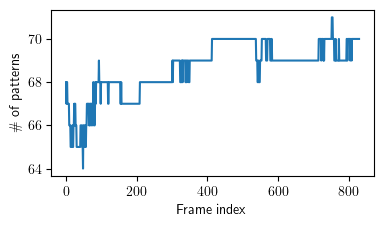

In [168]:
# import time

# Store the number of patterns on each image
count = np.zeros(stop-start)
# count = np.zeros(2)
# Store the tracked patterns in every images
i = start
frame = frames[i]
f = tp.locate(frame, R1, invert=False, minmass=minmass, separation=separation)
count[i-start] = len(f)
# Loop
for i in tqdm(range(start+1, stop, 1)):
# for i in tqdm(range(1, 2, 1)):
    frame = frames[i]
    ftemp = tp.locate(frame, R1, invert=False, minmass=minmass, separation=separation)
    # Artificially correct for 
    if ftemp['frame'].iloc[0] != i:
        ftemp = ftemp.reset_index(drop=True)
        for j in range(len(ftemp)):
            ftemp.at[j, 'frame'] = i
    count[i-start] = len(ftemp)
    f = pd.concat([f, ftemp], ignore_index=True)
    # time.sleep(0.1)
# Plot the nb of patterns per image
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 6/2.54))
ax.plot(np.arange(start, stop, 1), count)
# ax.plot(count)
ax.set(xlabel='Frame index', ylabel=r'\# of patterns')
plt.tight_layout()
plt.show()

In [169]:
f[:10]

,y,x,mass,size,ecc,signal,raw_mass,ep,frame
0,6.647138,903.633833,5743.908561,2.798443,0.046188,152.203302,18305.0,0.046658,0
1,30.101773,721.553772,6120.884670,2.868887,0.045068,153.487718,18733.0,0.043996,0
2,31.332258,791.783767,6171.619104,2.894233,0.040002,147.065637,19133.0,0.041770,0
3,37.987920,140.954184,5901.249526,2.744260,0.036935,161.194214,16947.0,0.057740,0
4,47.495504,680.335319,5713.082575,2.784831,0.040414,155.414342,17465.0,0.052943,0
5,54.475302,353.570692,6227.491202,2.906274,0.039938,156.056550,17990.0,0.048832,0
6,64.183929,79.726644,5946.204088,2.778343,0.041408,161.194214,16780.0,0.059477,0
7,66.646340,11.501135,5939.782008,2.822170,0.053257,161.194214,16664.0,0.060746,0
8,99.326667,17.694224,5748.404017,2.763355,0.049400,163.763046,16299.0,0.065120,0
9,113.639215,567.913901,6347.584102,2.884443,0.041367,152.845510,18678.0,0.044321,0


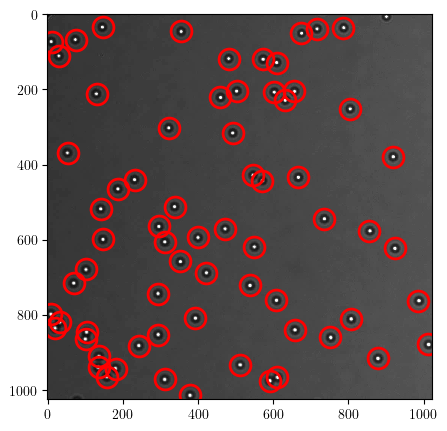

In [170]:
# Check tracking on one image
i = 88
# plt.figure()
# plt.imshow(frames[start+i])
tp.annotate(f[f['frame'] == start+i], frames[start+i])
plt.show()

In [171]:
# Check about duplicates
f[f.duplicated(subset=['frame', 'x', 'y'])]

,y,x,mass,size,ecc,signal,raw_mass,ep,frame


In [172]:
# f[f['frame'] == 19]

In [173]:
# plt.imshow(frames[35] - frames[36])

In [174]:
# Link trajectories

# tp.quiet()
t = tp.link(f, search_range=40, memory=25)

Frame 829: 70 trajectories present.


In [175]:
t.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
0,6.647138,903.633833,5743.908561,2.798443,0.046188,152.203302,18305.0,0.046658,0,0
36,611.145466,157.546606,6083.636605,2.937471,0.049242,156.698758,18096.0,0.048078,0,1
37,616.660064,931.128980,6776.579062,3.038482,0.038420,141.927973,20693.0,0.034884,0,2
38,619.934980,552.358608,6420.153609,2.929210,0.051337,151.561094,19187.0,0.041486,0,3
39,655.946409,348.351707,6303.271749,2.912828,0.049883,154.129926,18712.0,0.044120,0,4


In [176]:
# Filter too-short trajectories

t1 = tp.filter_stubs(t, threshold=50)

In [177]:
t1.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
frame,,,,,,,,,,
0,611.145466,157.546606,6083.636605,2.937471,0.049242,156.698758,18096.0,0.048078,0,1
0,616.660064,931.128980,6776.579062,3.038482,0.038420,141.927973,20693.0,0.034884,0,2
0,619.934980,552.358608,6420.153609,2.929210,0.051337,151.561094,19187.0,0.041486,0,3
0,655.946409,348.351707,6303.271749,2.912828,0.049883,154.129926,18712.0,0.044120,0,4
0,674.172106,88.446742,6119.600254,2.965450,0.036368,153.487718,18445.0,0.045753,0,5


In [178]:
# Compare the number of particles in the unfiltered and filtered data.
print('Before:', t['particle'].nunique())
print('After:', t1['particle'].nunique())

Before: 80
After: 73


In [179]:
# Filter with conditions on tracked particles
# t2 = t1[((t1['size'] < 30))]
t2 = t1[((t1['ecc'] < 0.9))]

In [180]:
t2.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
frame,,,,,,,,,,
0,611.145466,157.546606,6083.636605,2.937471,0.049242,156.698758,18096.0,0.048078,0,1
0,616.660064,931.128980,6776.579062,3.038482,0.038420,141.927973,20693.0,0.034884,0,2
0,619.934980,552.358608,6420.153609,2.929210,0.051337,151.561094,19187.0,0.041486,0,3
0,655.946409,348.351707,6303.271749,2.912828,0.049883,154.129926,18712.0,0.044120,0,4
0,674.172106,88.446742,6119.600254,2.965450,0.036368,153.487718,18445.0,0.045753,0,5


In [1]:
# t2[t2['frame'] == start]

In [182]:
print(t2['particle'].nunique())

73


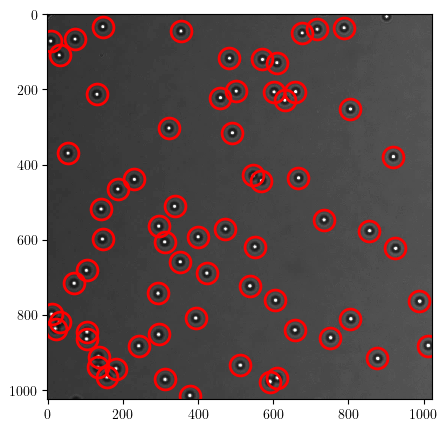

<Axes: >

In [183]:
i = 90
# plt.figure()
# plt.imshow(frames[start+i])
tp.annotate(t2[t2['frame'] == start+i], frames[start+i])

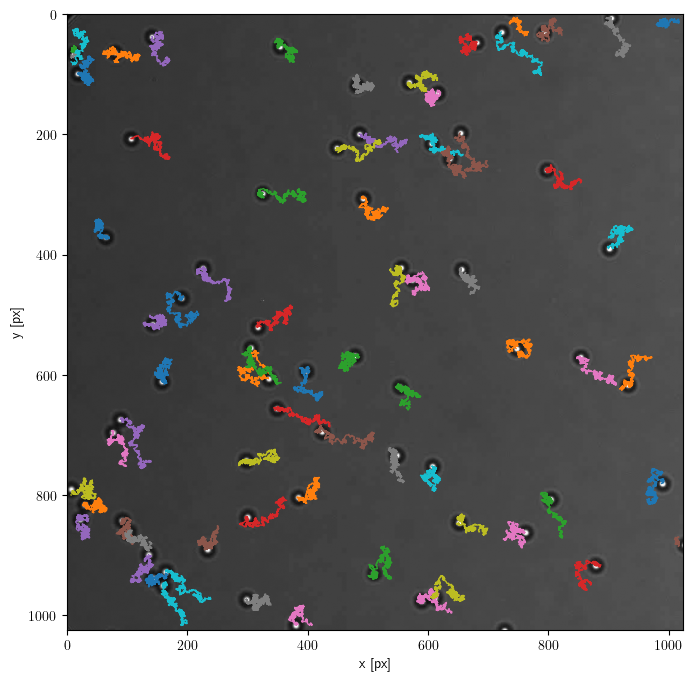

In [184]:
plt.figure(figsize=(15, 8))
plt.imshow(frames[start])
tp.plot_traj(t2);

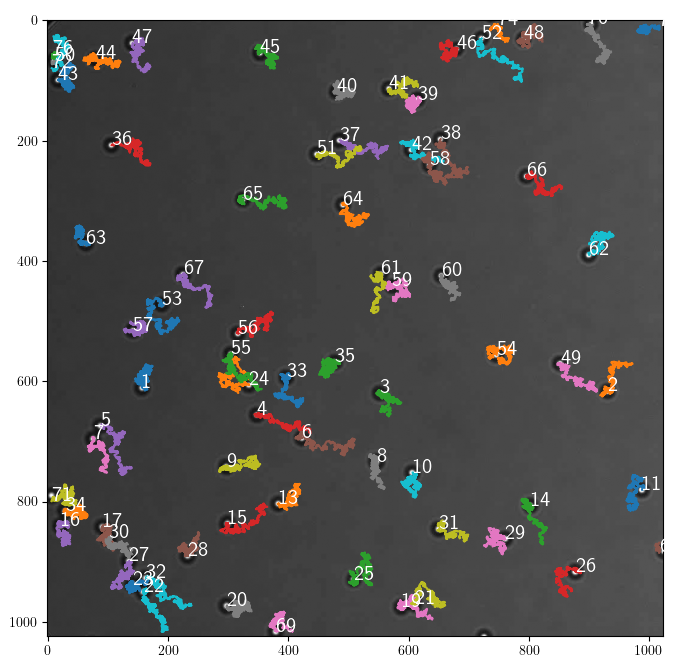

In [185]:
p = t2['particle'].unique()
N = t2['particle'].nunique()

plt.figure(figsize=(15, 8))
plt.imshow(frames[start])
for i in range(len(p)):
    x = t2[t2['particle'] == p[i]]['x']
    y = t2[t2['particle'] == p[i]]['y']
    plt.plot(x, y)
    plt.annotate(str(p[i]), (x.iloc[0], y.iloc[0]), c='white', size=15)
plt.show()

In [186]:
# Check the displacement between consecutive frames for a given particle
p_id = 0
traj = t[t['particle'] == p_id].sort_values('frame')
traj['dx'] = traj['x'].diff()
traj['dy'] = traj['y'].diff()
traj['displacement'] = (traj['dx']**2 + traj['dy']**2)**0.5
print(traj['displacement'].max() / (px*1e6))

19.996126873172653


In [187]:
# # Compute drifts

# d = tp.compute_drift(t2)

# d.plot()
# plt.show()

## Checks With MSDs: Last Selection of Tracked Particles 

In [188]:
# Get trajectories

tm = t2.copy() #tp.subtract_drift(t2.copy(), d)

In [189]:
# plt.figure()
# plt.imshow(frames[start])
# tp.plot_traj(tm)
# plt.show()

In [190]:
im = tp.imsd(tm, px*1e6, fps)  # microns per pixel, frames per second

In [191]:
# im

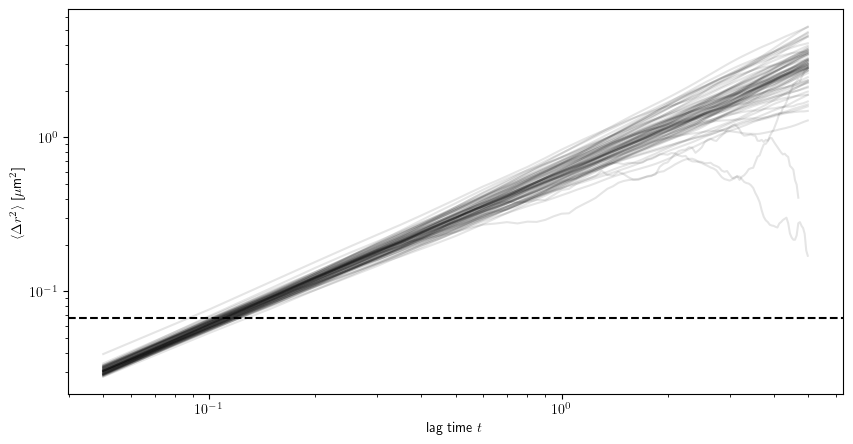

In [192]:
fig, ax = plt.subplots()
ax.plot(im.index, im, 'k-', alpha=0.1)  # black lines, semitransparent
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$')
ax.axhline(y=(2*px*1e6)**2, ls='--', c='k')
ax.set_xscale('log')
ax.set_yscale('log')

In [193]:
from scipy.optimize import curve_fit

/var/folders/w9/dz7zwdw15hv1n7xycd9mhbwh0000gn/T/ipykernel_98267/4251829029.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(f_diffusion, lag[lagmin:lagmax], em[lagmin:lagmax], p0=[1e-2, 200e-9])


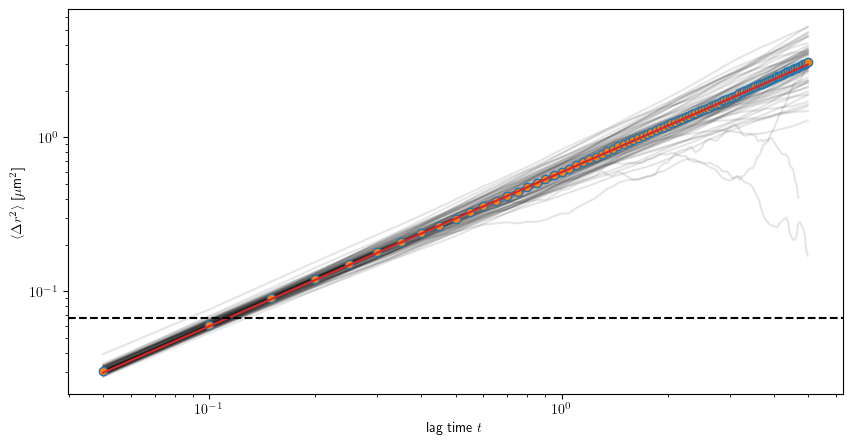

In [194]:
im = tp.imsd(tm, px*1e6, fps)  # microns per pixel, frames per second
em = tp.emsd(tm, px*1e6, fps)  # microns per pixel, frames per second

lag = em.index

f_diffusion = lambda t, D, d: 4*D*t+(2*d)**2

lagmin = 4
lagmax = 15
popt, _ = curve_fit(f_diffusion, lag[lagmin:lagmax], em[lagmin:lagmax], p0=[1e-2, 200e-9])

fig, ax = plt.subplots()
ax.plot(im.index, im, 'k-', alpha=0.1)  # black lines, semitransparent
ax.plot(em.index, em, 'o', mfc='tab:orange')  
ax.plot(em.index, f_diffusion(em.index, *popt), ls='-', c='tab:red')
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$')
ax.axhline(y=(2*px*1e6)**2, ls='--', c='k')
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()

In [195]:
print(popt)

[1.48379048e-01 2.00000000e-07]


# Save Final Trajectories

In [86]:
tm['x'] = tm['x'] * px
tm['y'] = tm['y'] * px
tm.to_pickle(savename)

In [91]:
# tm = pd.read_pickle(savename)

# More analysis